<a href="https://colab.research.google.com/github/roeytoo111/deep_learning/blob/master/t02_pytorchCont_feedForwardNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$
\newcommand{\bb}[1]{\boldsymbol{#1}}
$$

# Deep Learning - Tutorial 2: PyTorch example, Logistic Regression and intro to Feedforward Networks

In [ ]:
import torch
import time

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set()
import numpy as np
## Progress bar
from tqdm.notebook import tqdm

/tmp/ipython-input-911192750.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

Device cuda


## Learning by example: Continuous XOR
<div class="center-wrapper"><div class="video-wrapper"><iframe src="https://www.youtube.com/embed/schbjeU5X2g" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></div></div>

If we want to build a neural network in PyTorch, we could specify all our parameters (weight matrices, bias vectors) using `Tensors` (with `requires_grad=True`), ask PyTorch to calculate the gradients and then adjust the parameters.
But things can quickly get cumbersome if we have a lot of parameters.
In PyTorch, there is a package called `torch.nn` that makes building neural networks more convenient.

We will introduce the libraries and all additional parts you might need to train a neural network in PyTorch, using a simple example classifier on a simple yet well known example: XOR.
Given two binary inputs $x_1$ and $x_2$, the label to predict is $1$ if either $x_1$ or $x_2$ is $1$ while the other is $0$, or the label is $0$ in all other cases.
The example became famous by the fact that a single neuron, i.e. a linear classifier, cannot learn this simple function.
Hence, we will learn how to build a small neural network that can learn this function.
To make it a little bit more interesting, we move the XOR into continuous space and introduce some gaussian noise on the binary inputs.
Our desired separation of an XOR dataset could look as follows:

<center style="width: 100%"><img src="https://github.com/Lightning-AI/lightning-tutorials/raw/main/course_UvA-DL/01-introduction-to-pytorch/continuous_xor.svg" width="350px"></center>

### The model

The package `torch.nn` defines a series of useful classes like linear networks layers, activation functions, loss functions etc.
A full list can be found [here](https://pytorch.org/docs/stable/nn.html).
In case you need a certain network layer, check the documentation of the package before writing the layer yourself as the package likely contains the code for it already.
We import it below:

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

Additionally to `torch.nn`, there is also `torch.nn.functional`.
It contains functions that are used in network layers.
This is in contrast to `torch.nn` which defines them as `nn.Modules` (more on it below), and `torch.nn` actually uses a lot of functionalities from `torch.nn.functional`.
Hence, the functional package is useful in many situations, and so we import it as well here.

#### nn.Module

In PyTorch, a neural network is built up out of modules.
Modules can contain other modules, and a neural network is considered to be a module itself as well.
The basic template of a module is as follows:

In [ ]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        # Some init for my module

    def forward(self, x):
        # Function for performing the calculation of the module.
        pass

The forward function is where the computation of the module is taken place, and is executed when you call the module (`nn = MyModule(); nn(x)`).
In the init function, we usually create the parameters of the module, using `nn.Parameter`, or defining other modules that are used in the forward function.
The backward calculation is done automatically, but could be overwritten as well if wanted.

#### Simple classifier
We can now make use of the pre-defined modules in the `torch.nn` package, and define our own small neural network.
We will use a minimal network with a input layer, one hidden layer with tanh as activation function, and a output layer.
In other words, our networks should look something like this:

<center width="100%"><img src="https://github.com/Lightning-AI/lightning-tutorials/raw/main/course_UvA-DL/01-introduction-to-pytorch/small_neural_network.svg" width="300px"></center>

The input neurons are shown in blue, which represent the coordinates $x_1$ and $x_2$ of a data point.
The hidden neurons including a tanh activation are shown in white, and the output neuron in red.
In PyTorch, we can define this as follows:

In [ ]:
class SimpleClassifier(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        # Initialize the modules we need to build the network
        self.linear1 = nn.Linear(in_features=num_inputs, out_features=num_hidden) # y=x*w+b
        self.act_fn = nn.Tanh()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Perform the calculation of the model to determine the prediction
        x = self.linear1(x)
        x = self.act_fn(x)
        x = self.linear2(x)
        return x

For the examples, we will use a tiny neural network with two input neurons and four hidden neurons.
As we perform binary classification, we will use a single output neuron.
Note that we do not apply a sigmoid on the output yet.
This is because other functions, especially the loss, are more efficient and precise to calculate on the original outputs instead of the sigmoid output.
We will discuss the detailed reason later.

---

The `nn.Linear` layer in PyTorch is a fully connected layer that applies a linear transformation to the input data. It is commonly used in feedforward neural networks. The operation performed by the `nn.Linear` layer can be expressed as:

$$ y=xA^T+b $$


* $x$: The input tensor, typically of shape `(batch size,input features)`
* $A$: The weight matrix, learned during training, of shape `(output features,input features)`
* $b$: The bias vector, also learned during training, of shape `(output features)`
* $y$: The output tensor, of shape `(batch size, output features)`

You can read more about the `nn.linear` transformation [here](https://ecoagi.ai/topics/Python/nn-linear)

---

In [ ]:
model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)
# Printing a module shows all its submodules
print(model)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)


Printing the model lists all submodules it contains.
The parameters of a module can be obtained by using its `parameters()` functions, or `named_parameters()` to get a name to each parameter object.
For our small neural network, we have the following parameters:

In [ ]:
for name, param in model.named_parameters():
    print(f"Parameter {name}, shape {param.shape}, {param} \n")

Parameter linear1.weight, shape torch.Size([4, 2]), Parameter containing:
tensor([[-0.0270,  0.1869],
        [ 0.3103,  0.2609],
        [-0.6746, -0.4672],
        [ 0.3916,  0.4863]], requires_grad=True) 

Parameter linear1.bias, shape torch.Size([4]), Parameter containing:
tensor([ 0.0072,  0.5107, -0.0369,  0.1045], requires_grad=True) 

Parameter linear2.weight, shape torch.Size([1, 4]), Parameter containing:
tensor([[-0.2136,  0.1038, -0.2925, -0.4265]], requires_grad=True) 

Parameter linear2.bias, shape torch.Size([1]), Parameter containing:
tensor([0.4222], requires_grad=True) 



Each linear layer has a weight matrix of the shape `[output, input]`, and a bias of the shape `[output]`.
The tanh activation function does not have any parameters.
Note that parameters are only registered for `nn.Module` objects that are direct object attributes, i.e. `self.a = ...`.
If you define a list of modules, the parameters of those are not registered for the outer module and can cause some issues when you try to optimize your module.
There are alternatives, like `nn.ModuleList`, `nn.ModuleDict` and `nn.Sequential`, that allow you to have different data structures of modules.
We will use them in a few later tutorials and explain them there.

### The data

PyTorch also provides a few functionalities to load the training and
test data efficiently, summarized in the package `torch.utils.data`.

In [ ]:
import torch.utils.data as data

The data package defines two classes which are the standard interface for handling data in PyTorch: `data.Dataset`, and `data.DataLoader`.
The `Dataset` class provides an uniform interface to access the
training/test data, while the `DataLoader` makes sure to efficiently load
and stack the data points from the dataset into batches during training.

#### The dataset class

The dataset class summarizes the basic functionality of a dataset in a natural way.
To define a dataset in PyTorch, we simply specify two functions: `__getitem__`, and `__len__`.
The get-item function has to return the $i$-th data point in the dataset, while the len function returns the size of the dataset.
For the XOR dataset, we can define the dataset class as follows:

In [ ]:
class XORDataset(data.Dataset):
    def __init__(self, size, std=0.1):
        """XORDataset.

        args:
            size: Number of data points we want to generate
            std: Standard deviation of the noise (see generate_continuous_xor function)
        """
        super().__init__()
        self.size = size
        self.std = std
        self.generate_continuous_xor()

    def generate_continuous_xor(self):
        # Each data point in the XOR dataset has two variables, x and y, that can be either 0 or 1
        # The label is their XOR combination, i.e. 1 if only x or only y is 1 while the other is 0.
        # If x=y, the label is 0.
        data = torch.randint(low=0, high=2, size=(self.size, 2), dtype=torch.float32)
        label = (data.sum(dim=1) == 1).to(torch.long)
        # To make it slightly more challenging, we add a bit of gaussian noise to the data points.
        data += self.std * torch.randn(data.shape)

        self.data = data
        self.label = label

    def __len__(self):
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return self.size

    def __getitem__(self, idx):
        # Return the idx-th data point of the dataset
        # If we have multiple things to return (data point and label), we can return them as tuple
        data_point = self.data[idx]
        data_label = self.label[idx]
        return data_point, data_label

Let's try to create such a dataset and inspect it:

In [ ]:
dataset = XORDataset(size=200)
print("Size of dataset:", len(dataset))
print("Data point 0:", dataset[10])

Size of dataset: 200
Data point 0: (tensor([-0.2543, -0.0348]), tensor(0))


To better relate to the dataset, we visualize the samples below.

In [ ]:
def visualize_samples(data, label):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    plt.figure(figsize=(4, 4))
    plt.scatter(data_0[:, 0], data_0[:, 1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:, 0], data_1[:, 1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

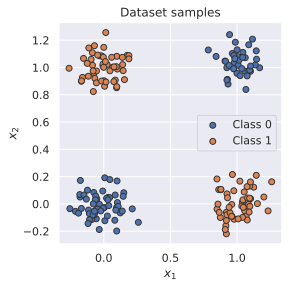

In [ ]:
visualize_samples(dataset.data, dataset.label)
plt.show()

#### The data loader class

The class `torch.utils.data.DataLoader` represents a Python iterable over a dataset with support for automatic batching, multi-process data loading and many more features.
The data loader communicates with the dataset using the function `__getitem__`, and stacks its outputs as tensors over the first dimension to form a batch.
In contrast to the dataset class, we usually don't have to define our own data loader class, but can just create an object of it with the dataset as input.
Additionally, we can configure our data loader with the following input arguments (only a selection, see full list [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)):

* `batch_size`: Number of samples to stack per batch
* `shuffle`: If True, the data is returned in a random order.
This is important during training for introducing stochasticity.
* `num_workers`: Number of subprocesses to use for data loading.
The default, 0, means that the data will be loaded in the main process which can slow down training for datasets where loading a data point takes a considerable amount of time (e.g. large images).
More workers are recommended for those, but can cause issues on Windows computers.
For tiny datasets as ours, 0 workers are usually faster.
* `pin_memory`: If True, the data loader will copy Tensors into CUDA pinned memory before returning them.
This can save some time for large data points on GPUs.
Usually a good practice to use for a training set, but not necessarily for validation and test to save memory on the GPU.
* `drop_last`: If True, the last batch is dropped in case it is smaller than the specified batch size.
This occurs when the dataset size is not a multiple of the batch size.
Only potentially helpful during training to keep a consistent batch size.

Let's create a simple data loader below:

In [ ]:
data_loader = data.DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
# next(iter(...)) catches the first batch of the data loader
# If shuffle is True, this will return a different batch every time we run this cell
# For iterating over the whole dataset, we can use "for batch in data_loader: ..."
data_inputs, data_labels = next(iter(data_loader))

# The shape of the outputs are [batch_size, d_1,...,d_N] where d_1,...,d_N are the
# dimensions of the data point returned from the dataset class
print("Data inputs", data_inputs.shape, "\n", data_inputs, "\n")
print("Data labels", data_labels.shape, "\n", data_labels)



Data inputs torch.Size([8, 2]) 
 tensor([[-0.0563, -0.1088],
        [-0.0669, -0.0621],
        [-0.0695, -0.0533],
        [ 0.9114, -0.1881],
        [-0.0902, -0.1145],
        [-0.0037, -0.0318],
        [ 1.0662,  0.8388],
        [ 0.1554,  0.9111]]) 

Data labels torch.Size([8]) 
 tensor([0, 0, 0, 1, 0, 0, 0, 1])


### Optimization

After defining the model and the dataset, it is time to prepare the optimization of the model.
During training, we will perform the following steps:

1. Get a batch from the data loader
2. Obtain the predictions from the model for the batch
3. Calculate the loss based on the difference between predictions and labels
4. Backpropagation: calculate the gradients for every parameter with respect to the loss
5. Update the parameters of the model in the direction of the gradients

We have seen how we can do step 1, 2 and 4 in PyTorch. Now, we will look at step 3 and 5.

#### Loss modules

We can calculate the loss for a batch by simply performing a few tensor operations as those are automatically added to the computation graph.
For instance, for binary classification, we can use Binary Cross Entropy (BCE) which is defined as follows:

$$\mathcal{L}_{BCE} = -\sum_i \left[ y_i \log x_i + (1 - y_i) \log (1 - x_i) \right]$$

where $y$ are our labels, and $x$ our predictions, both in the range of $[0,1]$.
However, PyTorch already provides a list of predefined loss functions which we can use (see [here](https://pytorch.org/docs/stable/nn.html#loss-functions) for a full list).
For instance, for BCE, PyTorch has two modules: `nn.BCELoss()`, `nn.BCEWithLogitsLoss()`.
While `nn.BCELoss` expects the inputs $x$ to be in the range $[0,1]$, i.e. the output of a sigmoid, `nn.BCEWithLogitsLoss` combines a sigmoid layer and the BCE loss in a single class.
This version is numerically more stable than using a plain Sigmoid followed by a BCE loss because of the logarithms applied in the loss function.
Hence, it is advised to use loss functions applied on "logits" where possible (remember to not apply a sigmoid on the output of the model in this case!).
For our model defined above, we therefore use the module `nn.BCEWithLogitsLoss`.

In [ ]:
loss_module = nn.BCEWithLogitsLoss()

#### Stochastic Gradient Descent

For updating the parameters, PyTorch provides the package `torch.optim` that has most popular optimizers implemented.
For now use the simplest one: `torch.optim.SGD`.
Stochastic Gradient Descent updates parameters by multiplying the gradients with a small constant, called learning rate, and subtracting those from the parameters (hence minimizing the loss).
Therefore, we slowly move towards the direction of minimizing the loss.
A good default value of the learning rate for a small network as ours is 0.1.

In [ ]:
# Input to the optimizer are the parameters of the model: model.parameters()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

The optimizer provides two useful functions: `optimizer.step()`, and `optimizer.zero_grad()`.
The step function updates the parameters based on the gradients as explained above.
The function `optimizer.zero_grad()` sets the gradients of all parameters to zero.
While this function seems less relevant at first, it is a crucial pre-step before performing backpropagation.
If we would call the `backward` function on the loss while the parameter gradients are non-zero from the previous batch, the new gradients would actually be added to the previous ones instead of overwriting them.
This is done because a parameter might occur multiple times in a computation graph, and we need to sum the gradients in this case instead of replacing them.
Hence, remember to call `optimizer.zero_grad()` before calculating the gradients of a batch.

### Training

Finally, we are ready to train our model.
As a first step, we create a slightly larger dataset and specify a data loader with a larger batch size.

In [ ]:
train_dataset = XORDataset(size=2500)
train_data_loader = data.DataLoader(train_dataset, batch_size=128, shuffle=True)

Now, we can write a small training function.
Remember our five steps: load a batch, obtain the predictions, calculate the loss, backpropagate, and update.
Additionally, we have to push all data and model parameters to the device of our choice (GPU if available).
For the tiny neural network we have, communicating the data to the GPU actually takes much more time than we could save from running the operation on GPU.
For large networks, the communication time is significantly smaller than the actual runtime making a GPU crucial in these cases.
Still, to practice, we will push the data to GPU here.

In [ ]:
# Push model to device. Has to be only done once
model.to(device)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)

In addition, we set our model to training mode.
This is done by calling `model.train()`.
There exist certain modules that need to perform a different forward
step during training than during testing (e.g. BatchNorm and Dropout),
and we can switch between them using `model.train()` and `model.eval()`.

In [ ]:
def train_model(model, optimizer, data_loader, loss_module, num_epochs=100):
    # Set model to train mode
    model.train()

    # Training loop
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Step 1: Move input data to device (only strictly necessary if we use GPU)
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            # Step 2: Run the model on the input data
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)  # Output is [Batch size, 1], but we want [Batch size]

            # Step 3: Calculate the loss
            loss = loss_module(preds, data_labels.float())

            # Step 4: Perform backpropagation
            # Before calculating the gradients, we need to ensure that they are all zero.
            # The gradients would not be overwritten, but actually added to the existing ones.
            optimizer.zero_grad()
            # Perform backpropagation
            loss.backward()

            # Step 5: Update the parameters
            optimizer.step()

In [ ]:
train_model(model, optimizer, train_data_loader, loss_module)

  0%|          | 0/100 [00:00<?, ?it/s]

#### Saving a model

After finish training a model, we save the model to disk so that we can load the same weights at a later time.
For this, we extract the so-called `state_dict` from the model which contains all learnable parameters.
For our simple model, the state dict contains the following entries:

In [ ]:
state_dict = model.state_dict()
print(state_dict)

OrderedDict({'linear1.weight': tensor([[-0.3428,  1.6862],
        [ 1.9362, -1.4165],
        [-3.4713, -3.4025],
        [ 1.6525,  1.8956]], device='cuda:0'), 'linear1.bias': tensor([-0.1970,  0.8565,  1.5537, -2.6461], device='cuda:0'), 'linear2.weight': tensor([[-2.3820, -2.7365, -5.0648, -3.5990]], device='cuda:0'), 'linear2.bias': tensor([-1.8864], device='cuda:0')})


To save the state dictionary, we can use `torch.save`:

In [ ]:
# torch.save(object, filename). For the filename, any extension can be used
torch.save(state_dict, "our_model.pt")

To load a model from a state dict, we use the function `torch.load` to
load the state dict from the disk, and the module function
`load_state_dict` to overwrite our parameters with the new values:

In [ ]:
# Load state dict from the disk (make sure it is the same name as above)
state_dict = torch.load("our_model.pt")

# Create a new model and load the state
new_model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)
new_model.load_state_dict(state_dict)

# Verify that the parameters are the same
print("Original model\n", model.state_dict())
print("\nLoaded model\n", new_model.state_dict())

Original model
 OrderedDict({'linear1.weight': tensor([[-0.3428,  1.6862],
        [ 1.9362, -1.4165],
        [-3.4713, -3.4025],
        [ 1.6525,  1.8956]], device='cuda:0'), 'linear1.bias': tensor([-0.1970,  0.8565,  1.5537, -2.6461], device='cuda:0'), 'linear2.weight': tensor([[-2.3820, -2.7365, -5.0648, -3.5990]], device='cuda:0'), 'linear2.bias': tensor([-1.8864], device='cuda:0')})

Loaded model
 OrderedDict({'linear1.weight': tensor([[-0.3428,  1.6862],
        [ 1.9362, -1.4165],
        [-3.4713, -3.4025],
        [ 1.6525,  1.8956]]), 'linear1.bias': tensor([-0.1970,  0.8565,  1.5537, -2.6461]), 'linear2.weight': tensor([[-2.3820, -2.7365, -5.0648, -3.5990]]), 'linear2.bias': tensor([-1.8864])})


A detailed tutorial on saving and loading models in PyTorch can be found
[here](https://pytorch.org/tutorials/beginner/saving_loading_models.html).

### Evaluation

Once we have trained a model, it is time to evaluate it on a held-out test set.
As our dataset consist of randomly generated data points, we need to
first create a test set with a corresponding data loader.

In [ ]:
test_dataset = XORDataset(size=500)
# drop_last -> Don't drop the last batch although it is smaller than 128
test_data_loader = data.DataLoader(test_dataset, batch_size=128, shuffle=False, drop_last=False)

As metric, we will use accuracy which is calculated as follows:

$$acc = \frac{\#\text{correct predictions}}{\#\text{all predictions}} = \frac{TP+TN}{TP+TN+FP+FN}$$

where TP are the true positives, TN true negatives, FP false positives, and FN the fale negatives.

When evaluating the model, we don't need to keep track of the computation graph as we don't intend to calculate the gradients.
This reduces the required memory and speed up the model.
In PyTorch, we can deactivate the computation graph using `with torch.no_grad(): ...`.
Remember to additionally set the model to eval mode.

In [ ]:
def eval_model(model, data_loader):
    model.eval()  # Set model to eval mode
    true_preds, num_preds = 0.0, 0.0

    with torch.no_grad():  # Deactivate gradients for the following code
        for data_inputs, data_labels in data_loader:
            # Determine prediction of model on dev set
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)
            preds = torch.sigmoid(preds)  # Sigmoid to map predictions between 0 and 1
            pred_labels = (preds >= 0.5).long()  # Binarize predictions to 0 and 1

            # Keep records of predictions for the accuracy metric (true_preds=TP+TN, num_preds=TP+TN+FP+FN)
            true_preds += (pred_labels == data_labels).sum()
            num_preds += data_labels.shape[0]

    acc = true_preds / num_preds
    print(f"Accuracy of the model: {100.0*acc:4.2f}%")

In [ ]:
eval_model(model, test_data_loader)

Accuracy of the model: 100.00%


If we trained our model correctly, we should see a score close to 100% accuracy.
However, this is only possible because of our simple task, and
unfortunately, we usually don't get such high scores on test sets of
more complex tasks.

#### Visualizing classification boundaries

To visualize what our model has learned, we can perform a prediction for every data point in a range of $[-0.5, 1.5]$, and visualize the predicted class as in the sample figure at the beginning of this section.
This shows where the model has created decision boundaries, and which points would be classified as $0$, and which as $1$.
We therefore get a background image out of blue (class 0) and orange (class 1).
The spots where the model is uncertain we will see a blurry overlap.
The specific code is less relevant compared to the output figure which
should hopefully show us a clear separation of classes:

/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


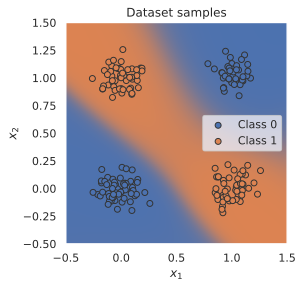

In [ ]:
@torch.no_grad()  # Decorator, same effect as "with torch.no_grad(): ..." over the whole function.
def visualize_classification(model, data, label):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    plt.figure(figsize=(4, 4))
    plt.scatter(data_0[:, 0], data_0[:, 1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:, 0], data_1[:, 1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

    # Let's make use of a lot of operations we have learned above
    model.to(device)
    c0 = torch.Tensor(to_rgba("C0")).to(device)
    c1 = torch.Tensor(to_rgba("C1")).to(device)
    x1 = torch.arange(-0.5, 1.5, step=0.01, device=device)
    x2 = torch.arange(-0.5, 1.5, step=0.01, device=device)
    xx1, xx2 = torch.meshgrid(x1, x2)  # Meshgrid function as in numpy
    model_inputs = torch.stack([xx1, xx2], dim=-1)
    preds = model(model_inputs)
    preds = torch.sigmoid(preds)
    # Specifying "None" in a dimension creates a new one
    output_image = (1 - preds) * c0[None, None] + preds * c1[None, None]
    output_image = (
        output_image.cpu().numpy()
    )  # Convert to numpy array. This only works for tensors on CPU, hence first push to CPU
    plt.imshow(output_image, origin="lower", extent=(-0.5, 1.5, -0.5, 1.5))
    plt.grid(False)


visualize_classification(model, dataset.data, dataset.label)
plt.show()

The decision boundaries might not look exactly as in the figure in the preamble of this section which can be caused by running it on CPU or a different GPU architecture.
Nevertheless, the result on the accuracy metric should be the approximately the same.

## Recap on Neural Network Training

<center style="width: 100%"><img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Ftse2.mm.bing.net%2Fth%3Fid%3DOIP.RC5f1iVMl8LMdldGs7-4fAHaD5%26pid%3DApi&f=1&ipt=8c061dff45f3eaeb99534bed126d83f310c88661db3b66d8551b3c07c11022f8&ipo=images" width="650px"></center>




## Linear Regression


Linear Regression is one of the most used algorithms in statistics and ML.
Technique to find relationships between two variables and predict how much change in the independent variable causes how much change in the dependent variable

<center style="width: 100%"><img src="https://cdn-images-1.medium.com/max/600/1*iuqVEjdtEMY8oIu3cGwC1g.png"></center>


#### A Simple NN for Linear Regression: Fully Connected

input dimention --> output dimention


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

In [ ]:
# define the dataset
house_prices_array = [3, 4, 5, 6, 7, 8, 9]
house_price_np = np.array(house_prices_array, dtype=np.float32)
house_price_np = house_price_np.reshape(-1, 1)
house_price_tensor = torch.from_numpy(house_price_np)

print(house_price_tensor)

tensor([[3.],
        [4.],
        [5.],
        [6.],
        [7.],
        [8.],
        [9.]])


In [ ]:
house_size = [ 4.5, 5, 5.5, 6.0, 6.5, 7.0, 7.5]
house_size_np = np.array(house_size, dtype=np.float32)
house_size_np = house_size_np.reshape(-1, 1)
house_size_tensor = torch.from_numpy(house_size_np)

print(house_size_tensor)

tensor([[4.5000],
        [5.0000],
        [5.5000],
        [6.0000],
        [6.5000],
        [7.0000],
        [7.5000]])


[Text(0.5, 0, 'House Price $'), Text(0, 0.5, 'House Sizes')]

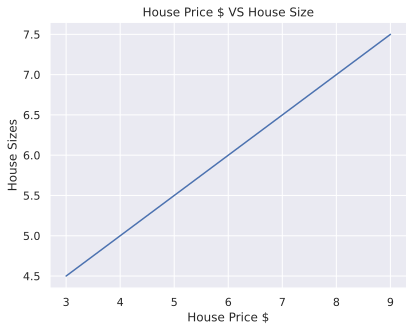

In [ ]:
# lets visualize our data

fig, ax = plt.subplots()
ax.plot(house_prices_array, house_size_np)
ax.set_title("House Price $ VS House Size")
ax.set(xlabel="House Price $", ylabel="House Sizes")


#### Steps:
1.   Construct a class for Linear Regression
2.   Define the model from this Linear Regression class
3.  Calculate the MSE (Mean squared error)
4.  Perform Backpropagation
5.  Perform Optimization to reduce the error (SGD i.e. stochastic gradient descent)
6.  Finally , make the prediction



In [ ]:
class LinearRegression(nn.Module):
    def __init__(self,input_size,output_size):
        # super function inherits from nn.Module so that we can access everything from nn.Module
        super(LinearRegression, self).__init__()
        # Linear function
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self,x):
        return self.linear(x)

input_dim = 1
output_dim = 1
model = LinearRegression(input_dim, output_dim)

Recall - The nn.Module is a base class for all neural network modules.

The `nn.Linear` applies a linear transformation to the incoming data:

`y = x*A^T + b` .

Where `x` is the input, `A` is the weight, `b` is the bias, and `y` is the output. You can read more about the `nn.linear` transformation [here](https://ecoagi.ai/topics/Python/nn-linear)




> `Input (x) -> Linear Layer (wx + b) -> Output (y)`





Lets define MSE as our loss function:

In [ ]:
#define the mse as a loss function
mse = nn.MSELoss()

Define the optimization which can be performed on the model prediction for best performance:

In [ ]:
# Optimization (find parameters that minimize error)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Train the model

In [ ]:
loss_list = []
iteration_number = 1001
for iteration in range(iteration_number):
    # perform optimization with zero gradient
    optimizer.zero_grad()
    results = model(house_price_tensor)
    loss = mse(results, house_size_tensor)
    # calculate derivative by stepping backward
    loss.backward()
    # Updating parameters
    optimizer.step()
    # store loss
    loss_list.append(loss.data)
    # print loss
    if(iteration % 50 == 0):
        print('epoch {}, loss {}'.format(iteration, loss.data))


epoch 0, loss 23.662479400634766
epoch 50, loss 0.6031216382980347
epoch 100, loss 0.4075544476509094
epoch 150, loss 0.27540165185928345
epoch 200, loss 0.18610039353370667
epoch 250, loss 0.12575587630271912
epoch 300, loss 0.08497852087020874
epoch 350, loss 0.05742350593209267
epoch 400, loss 0.03880344703793526
epoch 450, loss 0.026221107691526413
epoch 500, loss 0.017718782648444176
epoch 550, loss 0.011973349377512932
epoch 600, loss 0.008090898394584656
epoch 650, loss 0.005467358510941267
epoch 700, loss 0.0036945189349353313
epoch 750, loss 0.0024965479969978333
epoch 800, loss 0.0016870324034243822
epoch 850, loss 0.001139991101808846
epoch 900, loss 0.0007703495211899281
epoch 950, loss 0.0005205631023272872
epoch 1000, loss 0.0003517701698001474


[Text(0.5, 0, 'Number of Iterations'), Text(0, 0.5, 'Loss')]

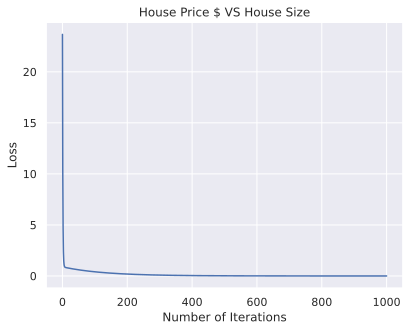

In [ ]:
fig2, ax2 = plt.subplots()
ax2.plot(range(iteration_number),loss_list)
ax2.set_title("House Price $ VS House Size")
ax2.set(xlabel="Number of Iterations", ylabel="Loss")

[Text(0.5, 0, 'House Price $'), Text(0, 0.5, 'House Size')]

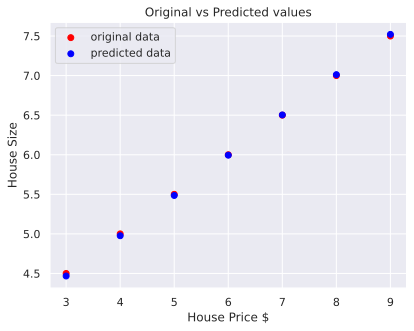

In [ ]:
# predict our car price
predicted = model(house_price_tensor).data.numpy()
fig3, ax3 = plt.subplots()
ax3.scatter(house_prices_array,house_size, label = "original data",color ="red")
ax3.scatter(house_prices_array, predicted, label = "predicted data",color ="blue")
ax3.legend()
ax3.set_title("Original vs Predicted values")
plt.xlabel("House Price $")
plt.ylabel("House Size")
ax3.set(xlabel="House Price $", ylabel="House Size")

## Binary Linear Classifier



*   Binary: distinguish between two categories
*   Linear: the classification is done using a linear function of the inputs. Decision boundaries are therefore straight lines

The formula for the model is:

$$y = activationFunction(xA^T + b)$$

* $x$: The input data (features).
* $A$: The weight vector, which determines the orientation of the decision boundary.
* $b$: The bias, which adjusts the position of the boundary.
* $Activation Function$: Decides the output (0 or 1) by applying a transformation to $xA^T+b$.


## Logistic Regression

### The sigmoid function

The **sigmoid** or **logistic function** is essential in binary classification problems. It is expressed as
$$\sigma(z) = \frac{1}{1+e^{-z}}$$
and here is what it looks like in 1D:

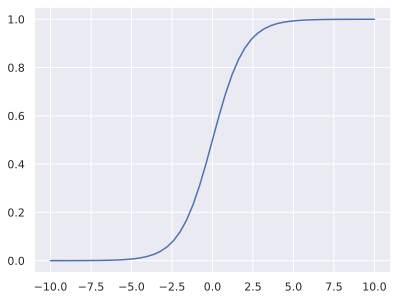

In [ ]:
# define parameters
# the bias:
b = 0
# the weight:
w = 1

def sigmoid(x1):
    # z is a linear function of x1
    z = w*x1 + b
    return 1 / (1+np.exp(-z))

# create an array of evenly spaced values
linx = np.linspace(-10,10,51)
plt.plot(linx, sigmoid(linx)) #bias = 0
# b=5
# plt.plot(linx, sigmoid(linx)) # bias = 5
# w=5
# plt.plot(linx, sigmoid(linx)) # bias =5 & weight = 5

Let's look at this function in more details:

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

* when $z$ goes to infinity, $e^{-z}$ goes to zero, and $\sigma (z)$ goes to one.
* when $z$ goes to minus infinity, $e^{-z}$ goes to infinity, and $\sigma (z)$ goes to zero.
* $\sigma(0) = 0.5$, since $e^0=1$.

It is important to note that the sigmoid is bound between 0 and 1, like a probability. And actually, in binary classification problems, the probability for an example to belong to a given category is produced by a sigmoid function. To classify our examples, we can simply use the output of the sigmoid: A given unknown example with value $x$ will be classified to category 1 if $\sigma(z) > 0.5$, and to category 0 otherwise.

**Excercise**: Now you can go back to the cell above, and play a bit with the `b` and `w` parameters, redoing the plot everytime you change one of these parameters.

* $b$ is the **bias**. Changing the bias simply moves the sigmoid along the horizontal axis. For example, if you choose $b=1$ and $w=1$, then $z = wx + b = 0$ at $x=-1$, and that's where the sigmoid will be equal to 0.5
* $w$ is the **weight** of variable $x$. If you increase it, the sigmoid evolves faster as a function of $x$ and gets sharper.

### Logistic regression as the simplest neural network



We will build the simplest neural network to classify our examples:

* Each example has one variable, so we need 1 input node on the input layer
* We're not going to use any hidden layer, as that would complicate the network
* We have two categories, so the output of the network should be a single value between 0 and 1, which is the estimated probability $p$ for an example to belong to category 1. Then, the probability to belong to category 0 is simply $1-p$. Therefore, we should have a single output neuron, the only neuron in the network.

The sigmoid function can be used in the output neuron. Indeed, it spits out a value between 0 and 1, and can be used as a classification probability.

We can represent our network in the following way:

![Neural network with 1 neuron](https://github.com/cbernet/maldives/raw/master/images/one_neuron.png)

In the output neuron:

* the first box performs a change of variable and computes the **weighted input** $z$ of the neuron
* the second box applies the **activation function** to the weighted input. Here, we choose the sigmoid $\sigma (z) = 1/(1+e^{-z})$ as an activation function

This simple network has only 2 tunable parameters, the weight $w$ and the bias $b$, both used in the first box. We see in particular that when the bias is very large, the neuron will **always be activated**, whatever the input. On the contrary, for very negative biases, the neuron is **dead**.

We can write the output simply as a function of $x$,

$$f(x) = \sigma(z) = \sigma(wx+b)$$
This is exactly the **logistic regression** classifier.

### Binary Logistic Regression Example

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-2214468870.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x, y, label='$y = \log(x)$', color='blue')
/tmp/ipython-input-2214468870.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log(x)$', fontsize=12)
/tmp/ipython-input-2214468870.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Graph of $y = \log(x)$', fontsize=14)


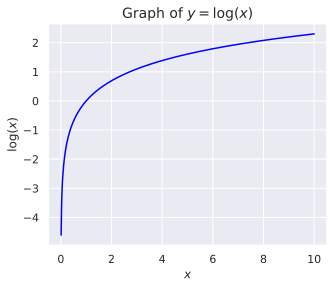

In [ ]:
# draw log(x) graph to understand cross ent loss
x = np.linspace(0.01, 10, 500)
# Compute log(x)
y = np.log(x)
# Plot log(x)
plt.figure(figsize=(5, 4))
plt.plot(x, y, label='$y = \log(x)$', color='blue')
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$\log(x)$', fontsize=12)
plt.title('Graph of $y = \log(x)$', fontsize=14)
plt.show()

#### Cross-Entropy Loss for Binary Classification

The cross-entropy loss quantifies how well the predicted probabilities ($y'$) match the true labels ($y$) in binary classification.

1. For $y=0$:
   
    The loss is:
     $$ℓ(y=0,y'​)=−log(1−y'​)$$

     * If the model predicts $y'≈0$, the loss is small (good prediction).
     * If the model predicts $y'​≈1$, the loss is large (bad prediction).

2.  For $y=1$:
    
    The loss is:
     $$ℓ(y=1,y')=−log(y'​)$$

     * If the model predicts $y'​≈1$, the loss is small (good prediction).
     * If the model predicts $y'≈0$, the loss is large (bad prediction).

These two cases are combined into a single formula for binary cross-entropy loss:

$$ℓ(y,y'​)=−[y *log(y')+(1−y)log(1−y'​)]$$



Loss function for binary logistic regression problems: minimize negative log likelihood

tensor([3.3535e-04, 3.3872e-04, 3.4212e-04,  ..., 9.9965e-01, 9.9966e-01,
        9.9966e-01], dtype=torch.float64)


<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-504390324.py:15: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(y_hat, loss_y_0, label='$\ell(y=0,\hat{y})$')
/tmp/ipython-input-504390324.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(y_hat, loss_y_1, label='$\ell(y=1,\hat{y})$')
/tmp/ipython-input-504390324.py:17: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat{y}$')
/tmp/ipython-input-504390324.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  loss_y_0 = -np.log(1-y_hat) #Calculates the loss when the true label y=0
/tmp/ipython-input-504390324.py:11: DeprecationWarning: __array_wra

Text(0.5, 1.0, 'Cross entropy loss')

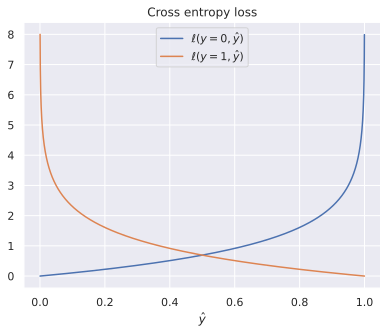

In [ ]:
def logistic(z):
    return 1 / (1 + torch.exp(-z))

x = np.arange(-8,8, .01)
x = torch.from_numpy(x)
y_hat = logistic(x)
print(y_hat)

# define loss components
loss_y_0 = -np.log(1-y_hat) #Calculates the loss when the true label y=0
loss_y_1 = -np.log(y_hat) #Calculates the loss when the true label y=1
# y_hat represents the predicted probability, where 0≤y'≤1

# plot the loss function
plt.plot(y_hat, loss_y_0, label='$\ell(y=0,\hat{y})$')
plt.plot(y_hat, loss_y_1, label='$\ell(y=1,\hat{y})$')
plt.xlabel('$\hat{y}$')
plt.legend()
plt.title('Cross entropy loss')

These smooth monotonic functions make it easier to calculate the gradients and minimize cost

#### End to end example
We'll load the Wisconsin breast cancer database from scikit learn

In [ ]:
#importing the dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

In [ ]:
data = load_breast_cancer()
x = data['data']
y = data['target']
print("shape of x: {}\nshape of y: {}\n".format(x.shape,y.shape))

print('features names:', data.feature_names)
print('target names:', data.target_names)

shape of x: (569, 30)
shape of y: (569,)

features names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
target names: ['malignant' 'benign']


Train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)
print(f'train: X={X_train.shape} y={y_train.shape}')
print(f'test : X={X_test.shape} y={y_test.shape}')

train: X=(398, 30) y=(398,)
test : X=(171, 30) y=(171,)


Here we standardizes the features in the dataset to have a mean of 0 and a standard deviation of 1.

This preprocessing step ensures that all features contribute equally to the learning process and improves the performance of many machine learning algorithms.

In [ ]:
# Step 1: Compute the mean (mu_X) of each feature in the training set
# - X_train is a matrix with shape (N, D), where N is the number of samples and D is the number of features.
# - axis=0 ensures the mean is calculated for each feature (column-wise), resulting in a vector of size (D,).
mu_X = np.mean(X_train, axis=0)  # (N, D) -> (D,)

# Step 2: Compute the standard deviation (sigma_X) of each feature in the training set (also column wise)
sigma_X = np.std(X_train, axis=0)

# Print the computed mean and standard deviation for each feature
print('Mean of training features (mu_X):', mu_X)
print('Standard deviation of training features (sigma_X):', sigma_X)

# Step 3: Standardize the training set
# - Subtract the mean and divide by the standard deviation for each feature.
# - Broadcasting automatically matches the shape of (N, D) with (D,) to perform the operation for all samples and features.
X_train_sc = (X_train - mu_X) / sigma_X

# Step 4: Standardize the test set.
# - Important: Use mu_X and sigma_X calculated from the training set to transform the test set. Ensures consistency and prevents data leakage.
X_test_sc = (X_test - mu_X) / sigma_X

# X_train_sc and X_test_sc are now standardized versions of the training and test datasets

Mean of training features (mu_X): [1.40938467e+01 1.93415327e+01 9.16989447e+01 6.50784171e+02
 9.57892714e-02 1.03143442e-01 8.84457681e-02 4.80487286e-02
 1.80492965e-01 6.27095729e-02 3.91917085e-01 1.19798166e+00
 2.77358819e+00 3.82153342e+01 6.98150251e-03 2.53617487e-02
 3.21848910e-02 1.15316784e-02 2.06816231e-02 3.80615352e-03
 1.62665603e+01 2.58163065e+01 1.07220678e+02 8.79696734e+02
 1.32259095e-01 2.57169975e-01 2.78709540e-01 1.14484601e-01
 2.92937688e-01 8.42292211e-02]
Standard deviation of training features (sigma_X): [3.48517093e+00 4.49479978e+00 2.40336307e+01 3.39867408e+02
 1.33323034e-02 5.32953640e-02 8.14064400e-02 3.86482491e-02
 2.80202233e-02 7.30462293e-03 2.30500508e-01 5.41489898e-01
 1.70502140e+00 3.42689188e+01 3.03056708e-03 1.86782469e-02
 3.34096567e-02 6.34593124e-03 8.73876377e-03 2.90684556e-03
 4.84371632e+00 6.32036643e+00 3.37316143e+01 5.64711073e+02
 2.26527320e-02 1.64498597e-01 2.21383104e-01 6.76307818e-02
 6.50551906e-02 1.90259097e-0

In [ ]:
#defining dataset class

class dataset(Dataset):
  def __init__(self,x,y):
    self.x = torch.tensor(x,dtype=torch.float32)
    self.y = torch.tensor(y,dtype=torch.float32)
    self.length = self.x.shape[0]

  def __getitem__(self,idx):
    return self.x[idx],self.y[idx]

  def __len__(self):
    return self.length

train_set = dataset(X_train_sc, y_train)
test_set = dataset(X_test_sc, y_test)

#DataLoader
train_loader = DataLoader(train_set,shuffle=True)
test_loader = DataLoader(test_set,shuffle=False)

print("Batch size:", train_loader.batch_size)
print("Number of batches: ", len(train_loader))


Batch size: 1
Number of batches:  398


The following code defines a binary logistic regression model:

* `BinaryLogisticRegression` Class:
    * Inherits from `torch.nn.Module`.
    * The constructor (`__init__`) initializes a fully connected layer (`self.fc`) with `input_dim` input features and `1` output. The layer includes a bias term.
    * The `forward` method passes input `x` through the fully connected layer, followed by a sigmoid activation to produce output between 0 and 1 (representing the probability of the positive class).

* Model Instantiation:
    * The model is created with `X_train.shape[1]` to match the number of input features in the training data.


In [ ]:
#Define model
class BinaryLogisticRegression(torch.nn.Module):

    def __init__(self, input_dim):

        super(BinaryLogisticRegression, self).__init__()
        self.fc = nn.Linear(input_dim, 1, bias=True) # define fully connected layer y=wx+b

    def forward(self, x):
        output = self.fc(x)
        output = torch.sigmoid(output) # Sigmoid activation

        return output

model = BinaryLogisticRegression(X_train.shape[1])

In [ ]:
X_train.shape[1]

30

In [ ]:
# Optimizer and cost function
learning_rate = 0.01
epochs = 201
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)
loss_fn = nn.BCELoss() #cross ent

The loop in sections (we'll put them together after)

In [ ]:
#train DEMO for understanding the steps

for i in range(1):

  for j,(data,label) in enumerate(train_loader):

    optimizer.zero_grad()

    print("Current data sample: ", data)
    print("Label: ", label)

    #calculate output
    output = model(data)
    print("Model prediction: ", output)

    #calculate loss
    loss = loss_fn(output,label.reshape(-1,1))
    print("Loss: ", loss)

    #train accuracy
    predicted = model(torch.tensor(X_train_sc, dtype=torch.float32))
    acc = (predicted.reshape(-1).detach().numpy().round() == y_train).mean()

    #backprop
    loss.backward()
    optimizer.step()

    break

Current data sample:  tensor([[-0.2823,  0.7116, -0.1947, -0.3572,  0.3308,  0.8473, -0.0171,  0.0769,
          0.1608,  1.4224, -0.8625, -0.5091, -0.7522, -0.6748, -0.5710,  0.2703,
         -0.2073, -0.5086,  0.5102,  0.1348, -0.3544,  0.5290, -0.2295, -0.4257,
          0.1166,  1.1127,  0.1693, -0.0279,  1.8425,  1.2284]])
Label:  tensor([1.])
Model prediction:  tensor([[0.8501]], grad_fn=<SigmoidBackward0>)
Loss:  tensor(0.1624, grad_fn=<BinaryCrossEntropyBackward0>)


Actual model training, we loop #ephocs times, each time training on all the batches in the train loader

In [ ]:
#train
losses = []

for i in range(epochs):

  for j,(data,label) in enumerate(train_loader):

    optimizer.zero_grad()

    #calculate output
    output = model(data)

    #calculate loss
    loss = loss_fn(output,label.reshape(-1,1))

    #train accuracy
    predicted = model(torch.tensor(X_train_sc,dtype=torch.float32))
    acc = (predicted.reshape(-1).detach().numpy().round() == y_train).mean()

    #backprop
    loss.backward()
    optimizer.step()
    losses.append(loss)

  if i%50 == 0:
    print("epoch {} | train loss : {} | train accuracy : {}".format(i,loss,acc))


#test accuracy
predicted = model(torch.tensor(X_test_sc,dtype=torch.float32))
acc = (predicted.reshape(-1).detach().numpy().round() == y_test).mean()
print("test accuracy : {}".format(acc))

epoch 0 | train loss : 1.0252233530714822e-14 | train accuracy : 0.9899497487437185
epoch 50 | train loss : 0.0003807077300734818 | train accuracy : 0.9899497487437185
epoch 100 | train loss : 0.15701468288898468 | train accuracy : 0.9899497487437185
epoch 150 | train loss : 0.0001445131638320163 | train accuracy : 0.9899497487437185
epoch 200 | train loss : 0.19463685154914856 | train accuracy : 0.9899497487437185
test accuracy : 0.9824561403508771


### Multi-class Logistic Regression (self study)

What if we have more than 2 classes? Can we still use logistic regression?

Naive solution:
*   Train C binary classifiers - one class vs. all the rest
*   Given a new example, run all the binary classifiers and choose the classifier that outputs the greatest probability.

Drawback : There is no probability distribution over the classes.

#### End to end example


In [ ]:
import torchvision
import torchvision.datasets as datasets
import torch
from torchvision import transforms

In [ ]:
#define data transformation which include normalization and converting to tensor

normalize = transforms.Normalize((0.1307,), (0.3081,))
totensor = transforms.ToTensor()
mnist_transforms = transforms.Compose([totensor, normalize])

In [ ]:
#load the train and test sets and apply the defined transformation

mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=mnist_transforms)
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=mnist_transforms)
print('train set len', len(mnist_trainset))
print('test set len', len(mnist_testset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]

train set len 60000
test set len 10000


In [ ]:
#create trainloaders

train_loader = torch.utils.data.DataLoader(mnist_trainset, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_testset, shuffle=False)

img size torch.Size([1, 28, 28])
label tensor(2)


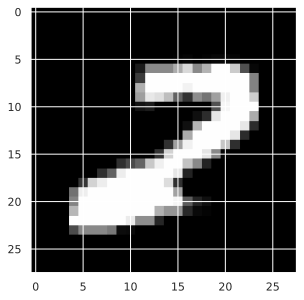

In [ ]:
#examples of what the data includes

image, label = next(iter(train_loader))
print('img size', image[0].size())
print('label', label[0])
plt.imshow(image[0].reshape(28,28), cmap="gray")

**Activation Function: Softmax**

*   Generalization of the logistic (sigmoid) function to multiple dimensions
*   Can generate a probability distribution for our C classes given raw prediction scores
*   The result of softmax is a vector of size C with elements in the range [0, 1] that all sum up to 1

Given a vector of scores z=(z_1, .. , z_c)

<center style="width: 100%"><img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fd33wubrfki0l68.cloudfront.net%2Fd6417f15d7db90091e6173ba01edb0355b5ce217%2F19fe2%2Fimages%2Fsoftmax-formula.png&f=1&nofb=1&ipt=5156459cfa99ecc4c1fc7d2ea586312c466cd0af8837fa97753abe829ce9db36&ipo=images" width="350px"></center>

Where:


*   **z** is the vector of raw outputs from the neural network
*   The value of e ≈ 2.718
*   The i-th entry in the softmax output vector softmax(z) can be thought of as the predicted probability of the test input belonging to class i.




In [ ]:
import torch
import torch.nn as nn

# Softmax function to apply across the rows (dim=1)
softmax = nn.Softmax(dim=1)

# Example input: batch of 3 samples, each with 4 class scores (logits)
input = torch.randn(3, 4)  # Random values simulating logits for 4 classes

# Apply Softmax to the input to get probabilities
output = softmax(input)

# Print the raw logits and the output probabilities
print("Input (Logits):\n", input)
print("\nOutput (Probabilities after Softmax):\n", output)

# Verify that probabilities sum to 1 for each sample
print("\nSum of probabilities for each sample (should be 1):\n", output.sum(dim=1))


Input (Logits):
 tensor([[-0.0898, -0.1042,  0.7123, -1.3276],
        [ 0.5024,  0.2956,  0.6977, -0.7383],
        [-0.9731, -2.1271,  0.1438,  0.6801]])

Output (Probabilities after Softmax):
 tensor([[0.2219, 0.2188, 0.4950, 0.0644],
        [0.3014, 0.2451, 0.3664, 0.0872],
        [0.1042, 0.0329, 0.3185, 0.5444]])

Sum of probabilities for each sample (should be 1):
 tensor([1.0000, 1.0000, 1.0000])


Explanation:

  *  Input: A tensor of shape `(3, 4)` representing 3 samples, each with 4 class logits (raw unnormalized scores).
  *  Softmax: Applies the Softmax function to the logits along dimension 1 (i.e., across each row, which corresponds to each sample). This converts the logits into a probability distribution where the sum of probabilities for each sample equals 1.
  *  Output: The result is a tensor of probabilities where each value in the row is between 0 and 1, and the sum of each row (for each sample) is 1.

We will use **LogSoftmax**

 Making learning much easier.

$$logSoftmax = log(softmax(z))$$


In [ ]:
#Define model
n_classes = 10
n_features = 28*28 #number of pixels in each image

class MultiClassLogisticRegression(torch.nn.Module):

    def __init__(self, input_dim, n_classes):

        super(MultiClassLogisticRegression, self).__init__()

        self.fc = nn.Linear(input_dim, n_classes, bias=True)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):

        output = self.fc(x)
        output = self.logsoftmax(output)
        return output

model = MultiClassLogisticRegression(n_features, n_classes)

In [ ]:
# the negative log likelihood loss
# -y^T * y^

nllloss = torch.nn.NLLLoss()

In [ ]:
#train - takes a while, run only if you really want to see results :)
epochs = 2
n_classes = 10
learning_rate = 0.005
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

for i in range(epochs):
    losses = []
    for j,(data,label) in enumerate(train_loader):

        optimizer.zero_grad()
        #flatten the image to vector of size 28*28
        data = data.view(-1,n_features)
        #calculate output
        y_hat = model(data)
        #calculate loss
        loss = nllloss(y_hat,label)
        #backprop
        loss.backward()
        optimizer.step()
        losses.append(loss.detach())

    print("epoch {} | train loss : {} ".format(i,np.mean(losses)))

epoch 0 | train loss : 0.4719841182231903 
epoch 1 | train loss : 0.43462297320365906 


In [ ]:
#test accuracy
def calculate_acc(dataset_loader):
    n_correct = 0
    n_total = 0
    for j,(data,label) in enumerate(dataset_loader):
        #flatten the image to vector of size 28*28
        data = data.view(-1,n_features)
        #calculate output
        y_hat = model(data)
        #get the prediction
        predictions = torch.argmax(y_hat, dim=1)
        n_correct += torch.sum(predictions == label).type(torch.float32)
        n_total += data.shape[0]
    acc = (n_correct / n_total).item()
    return acc

train_acc = calculate_acc(train_loader)
test_acc = calculate_acc(test_loader)
print("train accuracy : {}".format(train_acc))
print("test accuracy : {}".format(test_acc))

train accuracy : 0.9067333340644836
test accuracy : 0.9003000259399414


#### Limitations of logistic regression

Logistic regression is still a linear classifier decision boundaries are straight lines.

What if the data is not linearly separable? (back to out XOR example from last week)
